#   LABORATORIO Nº 1

## Alumnos:
- Araujo, Facundo
- Damaria, Leonel
- Orozco, Lucas
- Varas, María
- Yohena Tanoni, Brenda



## Importación de Librerías

In [89]:
%pip install matplotlib seaborn plotly scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [90]:
%pip install --upgrade nbformat


Note: you may need to restart the kernel to use updated packages.


* Esto de acá lo tuve que resolver con copilot, porque no podía cargar matplotlib

In [91]:
import sys
print(sys.executable)

c:\Users\Brenda\.anaconda-desktop\micromamba\envs\assistant\python.exe


In [92]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

import plotly.express as px

# Para importación de archivos y acceso a rutas. De apunte de Python
import glob
import os

## Creacion de Dataframe Original

In [93]:
# Creacion de Ruta a la Carpeta del Dataset
path_dataset = "Dataset de ventas/*.csv"

# Listar Archivos
file_list = glob.glob(path_dataset)

# Leer y concatenar los archivos
read_file = [pd.read_csv(f) for f in file_list]
original_df = pd.concat(read_file, ignore_index=True)

original_df.head()


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


### Aclaración: desde este momento, se va trabajar con copia del dataframe original para proteger la conservación de datos

In [94]:
df = original_df.copy(deep=True)
df.info

<bound method DataFrame.info of        ID de Pedido                    Producto Cantidad Pedida  \
0            176558        USB-C Charging Cable               2   
1               NaN                         NaN             NaN   
2            176559  Bose SoundSport Headphones               1   
3            176560                Google Phone               1   
4            176560            Wired Headphones               1   
...             ...                         ...             ...   
186845       259353      AAA Batteries (4-pack)               3   
186846       259354                      iPhone               1   
186847       259355                      iPhone               1   
186848       259356      34in Ultrawide Monitor               1   
186849       259357        USB-C Charging Cable               1   

       Precio Unitario Fecha de Pedido  \
0                11.95  04/19/19 08:46   
1                  NaN             NaN   
2                99.99  04/07/19 22:3

## Limpieza de datos
- Eliminar datos no numéricos.
- Eliminar filas incompletas

Se realizó una evaluación de la naturaleza de los datos cargados en el dataframe

 | **[id](ca://s?q=id)** | **[ID Pedido](ca://s?q=ID_Pedido)** | **[Producto](ca://s?q=Producto)** | **[Cantidad Pedida](ca://s?q=Cantidad_Pedida)** | **[Precio Unitario](ca://s?q=Precio_Unitario)** | **[Fecha Pedido](ca://s?q=Fecha_Pedido)** | **[Dirección](ca://s?q=Direccion)** |
|-----------------------|--------------------------------------|-----------------------------------|-----------------------------------------------|-----------------------------------------------|----------------------------------------------|----------------------------------------------|
| **[num](ca://s?q=num)** | **[num](ca://s?q=num)** | **[string](ca://s?q=string)** | **[num](ca://s?q=num)** | **[num](ca://s?q=num)** | **[num](ca://s?q=num)** | **[string](ca://s?q=string)** |


 Hay 7 columnas, de las cuales:

 - 3 tienen valores tipo string (nombre del producto, dirección, fecha)
 - 4 tiene valores tipo numérico (id, id pedido, cantidad pedida, precio).

 Si hay al realizar la limpieza de datos, eliminamos todos los numéricos, terminaríamos sin datos. Por lo que vamos a eliminar los datos no numericos solo de las tablas numéricas, y luego eliminaremos las filas incompletas del resto del dataframe.


In [95]:
print(" El dataframe original:") 
df.head(3)
print("La cantidad original de filas en el dataframe:", df.shape[0])
print(df.isnull().sum())
print(" Se eliminan valores no numéricos de las columnas Id de pedido, cantidad pedida, precio unitario")
col_num = ["ID de Pedido", "Cantidad Pedida", "Precio Unitario"]
df[col_num] = df[col_num].apply(pd.to_numeric, errors='coerce')
print("Nulos luego de convertir valores no numericos:")
print(df.isnull().sum())
print("Filas antes de la limpieza:", df.shape[0])
df = df.dropna()
print("Limpiando ...")
print("Filas luego de limpieza:", df.shape[0])

df.head(25)

 El dataframe original:
La cantidad original de filas en el dataframe: 186850
ID de Pedido          545
Producto              545
Cantidad Pedida       545
Precio Unitario       545
Fecha de Pedido       545
Dirección de Envio    545
dtype: int64
 Se eliminan valores no numéricos de las columnas Id de pedido, cantidad pedida, precio unitario
Nulos luego de convertir valores no numericos:
ID de Pedido          900
Producto              545
Cantidad Pedida       900
Precio Unitario       900
Fecha de Pedido       545
Dirección de Envio    545
dtype: int64
Filas antes de la limpieza: 186850
Limpiando ...
Filas luego de limpieza: 185950


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,176558.0,USB-C Charging Cable,2.0,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559.0,Bose SoundSport Headphones,1.0,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560.0,Google Phone,1.0,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560.0,Wired Headphones,1.0,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561.0,Wired Headphones,1.0,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"
6,176562.0,USB-C Charging Cable,1.0,11.95,04/29/19 13:03,"381 Wilson St, San Francisco, CA 94016"
7,176563.0,Bose SoundSport Headphones,1.0,99.99,04/02/19 07:46,"668 Center St, Seattle, WA 98101"
8,176564.0,USB-C Charging Cable,1.0,11.95,04/12/19 10:58,"790 Ridge St, Atlanta, GA 30301"
9,176565.0,Macbook Pro Laptop,1.0,1700.00,04/24/19 10:38,"915 Willow St, San Francisco, CA 94016"
10,176566.0,Wired Headphones,1.0,11.99,04/08/19 14:05,"83 7th St, Boston, MA 02215"


## Preparación de los datos:
- Ajustar los tipos de datos de cada atributo
- Extraer características importantes para el análisis como meses, horas, ciudades etc.

Vamos a crear una clasificación con variables para mejor uso.
- Variable temporal: para poder ver periodos de alta y bajas ventas.
- Variables producto: para saber cuales son los favoritos de los clientes
- Variables de lugar: para poder ver distribución geográfica de las ventas.

### Ajustar los tipos de datos de cada atributo

Para ajustar datos, comenzamos de izquierda a derecha según las columnas.
1. ID Pedido: se lo convierte a número entero y luego en String. No va a ser necesario realizar operaciones entre los números de ID del pedido.

In [96]:
df['ID de Pedido'] = df['ID de Pedido'].astype(int).astype(str)
df.head(2)

,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,176558,USB-C Charging Cable,2.0,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1.0,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"


2. Cantidad Pedida: se ajusta el resultado a valores enteros. Al ser elementos tecnoólgicos, no se venden por fracciones.

In [97]:
df['Cantidad Pedida'] = df['Cantidad Pedida'].astype(int)
df.head(2)

,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"


3. Precio Unitario: nos aseguramos que sea  un valor numérico decimal

In [98]:
df['Precio Unitario'] = df['Precio Unitario'].astype(float)

4. Fecha de Pedido: se ajusta a valores tipo datetime para poder realizar analisis de fechas y horarios de mayores ventas

In [99]:
df['Fecha de Pedido'] = pd.to_datetime(df['Fecha de Pedido'])
df.head(2)

C:\Users\Brenda\AppData\Local\Temp\ipykernel_29580\579378820.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha de Pedido'] = pd.to_datetime(df['Fecha de Pedido'])


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215"


### Extraer características importantes para el análisis como meses, horas, ciudades etc.
Se extraen las características más importantes para poder mejorar la interpretación de los resultados. Al separar más claramente los meses, la hora de la compra, y sucursal; podremos obtener mapas de calor de ventas de ubicación y hora de ventas.

In [100]:
# Extraccion de Mes
df['Mes'] = df['Fecha de Pedido'].dt.month

# Extraccion de Día
df['Dia'] = df['Fecha de Pedido'].dt.day


# Extraccion de hora
df['Hora'] = df['Fecha de Pedido'].dt.hour

# Extraccion de Ciudad
df['Ciudad'] = df['Dirección de Envio'].apply(lambda x: x.split(',')[1].strip())

# Extraccion de Venta
df['Venta'] = df['Cantidad Pedida'] * df['Precio Unitario']


df.head()


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio,Mes,Dia,Hora,Ciudad,Venta
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,19,8,Dallas,23.90
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,7,22,Boston,99.99
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,14,Los Angeles,600.00
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,14,Los Angeles,11.99
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,30,9,Los Angeles,11.99


## Análisis de Datos

Ejemplo:
- Examinar las horas del día en que las ventas son más frecuentes.
- Determinar el mejor momento para mostrar publicidad.

1. Comportamiento de las ventas en los distintos meses:
● ¿Cómo variaron las ventas a lo largo de los diferentes meses? = meses con mas ventas
● ¿Hubo algún mes que se destacó en términos de ventas? = diciembre
● ¿Cuál es el ingreso total generado por mes? = tabla?

### Meses con más ventas
Fechas Festivas

In [101]:

# agrupamos por mes, los sumamos y ordenamos de mayor a menor
meses_mas_ventas = df.groupby('Mes')['Venta'].sum().sort_values(ascending=False)
print("los meses con mas ventas: ", meses_mas_ventas)

los meses con mas ventas:  Mes
12    4613443.34
10    3736726.88
4     3390670.24
11    3199603.20
5     3152606.75
3     2807100.38
7     2647775.76
6     2577802.26
8     2244467.88
2     2202022.42
9     2097560.13
1     1822256.73
Name: Venta, dtype: float64


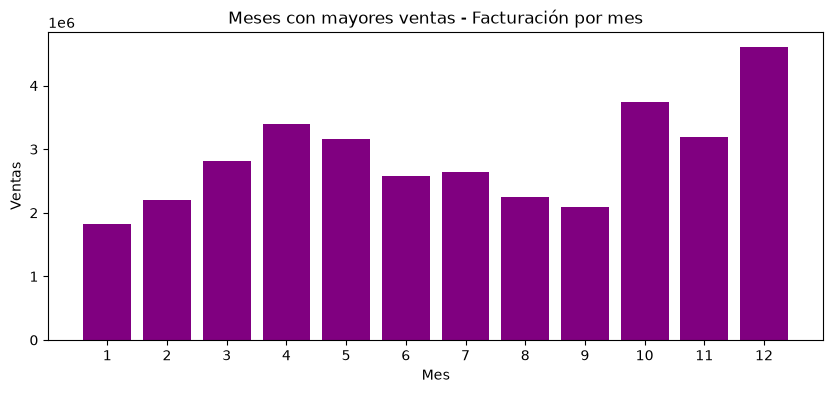

In [116]:
# Facturación
plt.figure(figsize=(10,4))
plt.bar(meses_mas_ventas.index, meses_mas_ventas.values, color="purple")
plt.title("Meses con mayores ventas - Facturación por mes")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.xticks(meses_mas_ventas.index)
plt.show()

### Ciudades con más ventas

Lista de las ciudades del dataframe

In [102]:
sorted(df['Ciudad'].unique())



['Atlanta',
 'Austin',
 'Boston',
 'Dallas',
 'Los Angeles',
 'New York City',
 'Portland',
 'San Francisco',
 'Seattle']

In [103]:
# Agrupamos por Ciudad, sumamos las ventas y ordenamos de mayor a menor
ciudades_con_mas_ventas = df.groupby('Ciudad')['Venta'].sum().sort_values(ascending=False)

# Mostrar todas las ciudades ordenadas
print(ciudades_con_mas_ventas)


print("\nLa ciudad con más ventas fue:")
print(ciudades_con_mas_ventas.head(1))

Ciudad
San Francisco    8262203.91
Los Angeles      5452570.80
New York City    4664317.43
Boston           3661642.01
Atlanta          2795498.58
Dallas           2767975.40
Seattle          2747755.48
Portland         2320490.61
Austin           1819581.75
Name: Venta, dtype: float64

La ciudad con más ventas fue:
Ciudad
San Francisco    8262203.91
Name: Venta, dtype: float64


#### Ventas Por Ciudades con Más habitantes
Para poder analizar el alcance en cada ciudad, también tenemos que tener en cuenta, no solo la cantidad total de los ingresos de dinero por ciudad, sino también en cual ciudad más porcentaje de la población es un comprador para no perder la fidelización de los clientes, como en cuales hay que aumentar la publicidad para llegar a más personas.

Tomamos de Google la siguiente información de las Ciudades que aparecen en el dataset.

| **[Ciudad](ca://s?q=Ciudad)** | **[Cantidad de Habitantes](ca://s?q=Cantidad_de_Habitantes)** |
|-------------------------------|------------------------------|
| **[Atlanta](ca://s?q=Atlanta)** | **[530000](ca://s?q=530000)** |
| **[Austin](ca://s?q=Austin)** | **[1000000](ca://s?q=1000000)** |
| **[Boston](ca://s?q=Boston)** | **[675000](ca://s?q=675000)** |
| **[Dallas](ca://s?q=Dallas)** | **[1300000](ca://s?q=1300000)** |
| **[Los Angeles](ca://s?q=Los_Angeles)** | **[3980000](ca://s?q=3980000)** |
| **[New York](ca://s?q=New_York)** | **[8260000](ca://s?q=8260000)** |
| **[Portland](ca://s?q=Portland)** | **[652503](ca://s?q=652503)** |
| **[San Francisco](ca://s?q=San_Francisco)** | **[827526](ca://s?q=827526)** |
| **[Seattle](ca://s?q=Seattle)** | **[781000](ca://s?q=781000)** |


Para eso, creamos un pequeño dataset con las ciudades y sus habitantes


In [104]:


cant_habitantes = {
    'Ciudad': ['Atlanta', 'Austin', 'Boston', 'Dallas', 'Los Angeles', 'New York City', 'Portland', 'San Francisco', 'Seattle'],
    'Habitantes': [530000, 1000000, 675000, 1300000, 3980000, 8260000, 652500, 827526, 781000] 
}
df_habitantes = pd.DataFrame(cant_habitantes)

!!!! Acá hay que terminar la idea: 
- puede ser, incorporar esta información al otro dataset con un merge para poder hacer comparación.
- descartar la idea por irse por las ramas: no tenemos id de comprador, no sabemos si es lo mismo la dirección de envio que de donde compra, si o no la misma persona que compra mucho. Creo que muchas más dudas como llevarlo a cabo. Pero, si vemos el ejemplo de Atlanta, tiene casi la mitad de habitantes que Austin; pero vendió más.

In [105]:
# comparación entre ventas y cantidad de habitantes


# Convertimos tu variable de ventas (que es una Serie) a un DataFrame plano
df_ventas_ciudad = ciudades_con_mas_ventas.reset_index()




# 3. Cruzamos (Merge) ambos DataFrames usando 'Ciudad' como clave
df_comparacion = pd.merge(df_ventas_ciudad, df_habitantes, on='Ciudad')

# 4. Creamos una métrica fundamental: Ventas per cápita (Ventas por habitante)
df_comparacion['Ventas_per_capita ($)'] = df_comparacion['Venta'] / df_comparacion['Habitantes']

# 5. Ordenamos por el nuevo indicador de mayor a menor
df_comparacion = df_comparacion.sort_values(by='Ventas_per_capita ($)', ascending=False)

print(df_comparacion)

          Ciudad       Venta  Habitantes  Ventas_per_capita ($)
0  San Francisco  8262203.91      827526               9.984223
3         Boston  3661642.01      675000               5.424655
4        Atlanta  2795498.58      530000               5.274526
7       Portland  2320490.61      652500               3.556307
6        Seattle  2747755.48      781000               3.518253
5         Dallas  2767975.40     1300000               2.129212
8         Austin  1819581.75     1000000               1.819582
1    Los Angeles  5452570.80     3980000               1.369993
2  New York City  4664317.43     8260000               0.564687


### Ventas por Ciudad por mes

In [106]:


# Extraer la Ciudad separando la cadena de texto por las comas
# df['Ciudad'] = df['Dirección de Envio'].apply(lambda x: str(x).split(',')[1].strip() if pd.notnull(x) else x)

ventas_ciudad_mes = df.groupby(['Mes', 'Ciudad'])['Venta'].sum().reset_index()
print(ventas_ciudad_mes)


     Mes         Ciudad       Venta
0      1        Atlanta   149159.54
1      1         Austin    88087.06
2      1         Boston   201088.49
3      1         Dallas   143462.51
4      1    Los Angeles   288601.90
..   ...            ...         ...
103   12    Los Angeles   684044.84
104   12  New York City   646770.83
105   12       Portland   303714.11
106   12  San Francisco  1106601.27
107   12        Seattle   387317.93

[108 rows x 3 columns]


In [107]:
# 1.Elegir el mes
mes_elegido = 12


ventas_del_mes = ventas_ciudad_mes[ventas_ciudad_mes['Mes'] == mes_elegido]

# 3. Ordena los resultados de mayor a menor para facilitar el análisis
ventas_del_mes = ventas_del_mes.sort_values('Venta', ascending=False)

# 4. Imprime el resultado mostrando solo Ciudad y Venta (el mes ya lo sabemos)
print(f"--- Ventas por ciudad en el mes {mes_elegido} ---")
print(ventas_del_mes[['Ciudad', 'Venta']])

--- Ventas por ciudad en el mes 12 ---
            Ciudad       Venta
106  San Francisco  1106601.27
103    Los Angeles   684044.84
104  New York City   646770.83
101         Boston   509599.16
107        Seattle   387317.93
102         Dallas   380718.85
99         Atlanta   360899.26
105       Portland   303714.11
100         Austin   233777.09


C:\Users\Brenda\AppData\Local\Temp\ipykernel_29580\3796324435.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ventas_del_mes, x='Ciudad', y='Venta', palette='viridis')


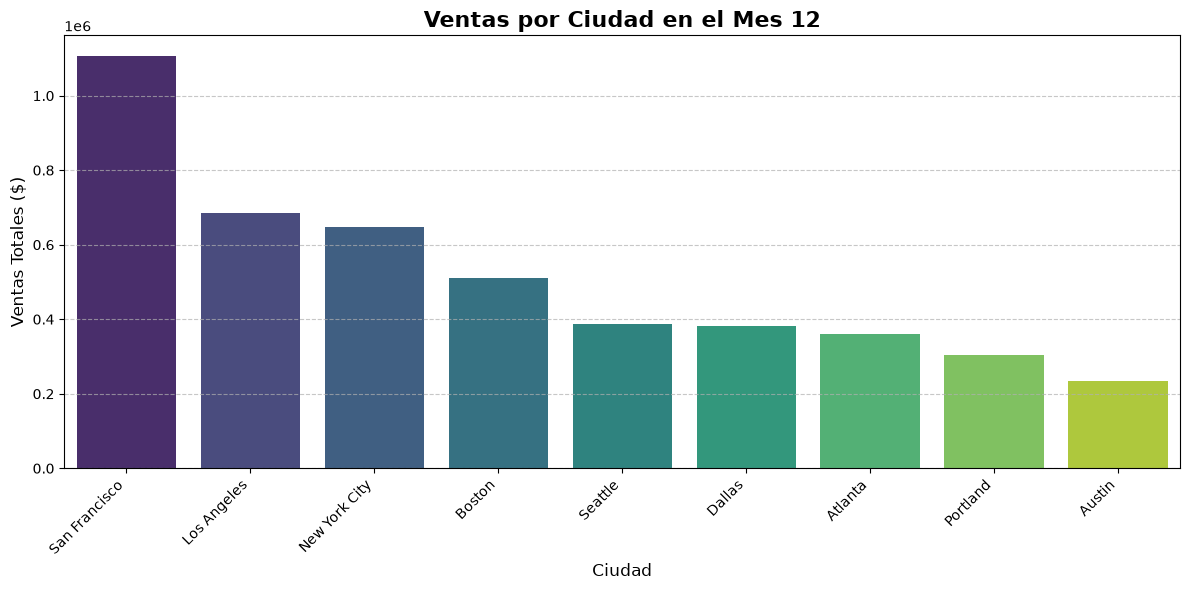

In [108]:
plt.figure(figsize=(12, 6))
# Creamos el gráfico de barras usando el dataframe ya filtrado y ordenado
sns.barplot(data=ventas_del_mes, x='Ciudad', y='Venta', palette='viridis')

# Personalizamos los títulos y etiquetas
plt.title(f'Ventas por Ciudad en el Mes {mes_elegido}', fontsize=16, fontweight='bold')
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('Ventas Totales ($)', fontsize=12)

# Rotamos los nombres de las ciudades 45 grados para que no se superpongan
plt.xticks(rotation=45, ha='right') 

# Agregamos una grilla horizontal sutil para facilitar la lectura de los valores
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajustamos automáticamente los márgenes para que no se corte ningún texto
plt.tight_layout()

# Mostramos el gráfico
plt.show()

### Ingreso por hora

In [109]:
# Ingresos por Hora
pedidos_por_hora = df.groupby('Hora')['ID de Pedido'].count()
print(pedidos_por_hora)

# Ingresos Totales por Hora
ingresos_por_hora = df.groupby('Hora')['Venta'].sum()
print(ingresos_por_hora)

# Productos por hora
productos_por_hora = df.groupby('Hora')['Cantidad Pedida'].sum()
print(productos_por_hora)

Hora
0      3910
1      2350
2      1243
3       831
4       854
5      1321
6      2482
7      4011
8      6256
9      8748
10    10944
11    12411
12    12587
13    12129
14    10984
15    10175
16    10384
17    10899
18    12280
19    12905
20    12228
21    10921
22     8822
23     6275
Name: ID de Pedido, dtype: int64
Hora
0      713721.27
1      460866.88
2      234851.44
3      145757.89
4      162661.01
5      230679.82
6      448113.00
7      744854.12
8     1192348.97
9     1639030.58
10    1944286.77
11    2300610.24
12    2316821.34
13    2155389.80
14    2083672.73
15    1941549.60
16    1904601.31
17    2129361.61
18    2219348.30
19    2412938.54
20    2281716.24
21    2042000.86
22    1607549.21
23    1179304.44
Name: Venta, dtype: float64
Hora
0      4428
1      2619
2      1398
3       928
4       937
5      1493
6      2810
7      4556
8      7002
9      9816
10    12308
11    14005
12    14202
13    13685
14    12362
15    11391
16    11662
17    12229
18    13802


### Cantidad Pedida 
- Media
- Desvío Estándar: ver cuantos productos compran 
- Mínimo y Máximo de las compras
Cuartiles (Q1 - Q3)

### Percentiles de Cantidad Pedida para Stock de Seguridad
Demanda diaria
Percentil de demanda diaria (90 y 95)
Esto sirve para calcular stock
Stock de Seguridad
Cálculo del Stock de Seguridad

### Mejores Productos

ventas = ventas_df.groupby("Product").agg({"Sales":"sum"}) #Agrupamos los productos, y en la columna sales ponemos la suma

ventas = ventas.sort_values("Sales", ascending=False)


si cambia a lo largo del año


In [110]:


# mejores_productos = 

### Segmentación del Catálogo por Percentiles de Precio
Low-Ticket P<Q1
Mid-Ticket Q1>P>=Q3
Higth-ticket PQ3


### Mejores Productos por Mes

### Cantidad de venta de los 10 mejores productos según su precio
Varia sus ventas si están en oferta?

### Ranking de venta por mes
La demanda estacional se produce cuando las ventas de ciertos productos se concentran fuertemente en épocas específicas del año (debido al clima, festivos o eventos comerciales)

### Ciclo de Vida del Producto

### Precio Unitario
Media
Desvío Estándar
Minimo y maximo
Cuartil, mediana
rango intercuartil

### Cálculo de KPIs

### Robust Scaling vs. Z-Score
El escalado es vital para preparar los datos antes de aplicar modelos
Z-score (Estandarización): usa la media y el desvio
Robust Scaling (Escalado Robusto) = usa media y el IQR



### Normalización por Categoría e Inferencia ANOVA
Para comparar precios de forma justa entre categorías tan dispares como "Cables" y "Laptops", aplicamos Normalización por Categoría (Z-score calculado individualmente dentro de cada grupo)
ANOVA en Precios Brutos: Obtiene un p-valor = $0.0000$ (se rechaza la hipótesis nula; las diferencias de escala entre categorías son gigantescas y reales).
ANOVA en Precios Normalizados por Categoría: Obtiene un p-valor = $1.0000$. Al normalizar, el promedio de cada categoría se centró exactamente en $0$.



### Formulación de Hipótesis y Pruebas Estadísticas


#### relación entre el Precio Unitario y la Cantidad Pedida 
Pearson :
Spearman :

## Analisis Gráfico

####  Prueba de Hipótesis: Mann-Whitney U (Mejora de variables)
Aplicamos la prueba no paramétrica de Mann-Whitney U para comparar el volumen de compra entre productos baratos (Low-Ticket) y caros (High-Ticket):Hipótesis Nula ($H_0$): La distribución de la cantidad pedida es idéntica entre productos de bajo costo y alto costo.Hipótesis Alternativa ($H_1$): La distribución de la cantidad pedida difiere significativamente entre ambos grupos.


### Tipos de Error en la Toma de Decisiones de Negocio
Error Tipo I (Falso Positivo): Rechazar H cuando es verdadera.
Ejemplo de negocio: Concluir que una campaña de marketing con descuentos aumentó significativamente las ventas (rechazar que las ventas se mantuvieron iguales), cuando en realidad el aumento fue fluctuación aleatoria. La empresa gastará presupuesto en una promoción inútil.
Error Tipo II (Falso Negativo): No rechazar H cuando es falsa (baja potencia estadística).Ejemplo de negocio: Concluir que una nueva tanda de productos importados no tiene una tasa de falla mayor que la estándar (no rechazar la igualdad), cuando en realidad sí venían fallados pero el tamaño de muestra fue muy chico para detectarlo [9]. Esto generará costos masivos ocultos por devoluciones y reclamos de garantía postventa


## Media y Mediana por transacción
Puede verse general y por mes

### Ciudades con más ventas

### Meses con más ventas

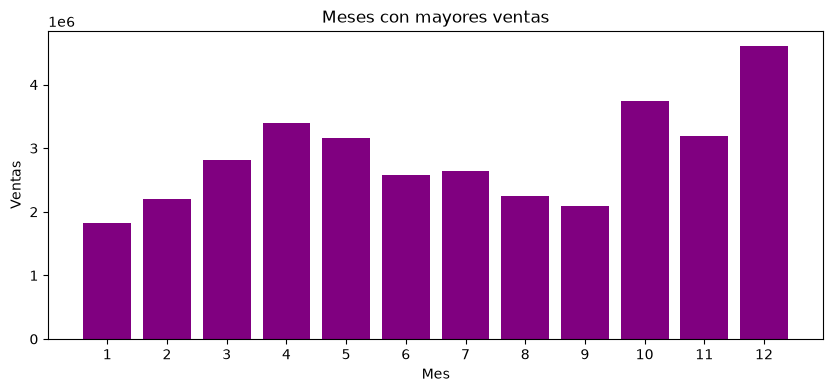

In [111]:
plt.figure(figsize=(10,4))
plt.bar(meses_mas_ventas.index, meses_mas_ventas.values, color="purple")
plt.title("Meses con mayores ventas")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.xticks(meses_mas_ventas.index)
plt.show()

C:\Users\Brenda\AppData\Local\Temp\ipykernel_29580\3608583651.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_meses_ventas, x="Mes", y="Venta", palette="magma")


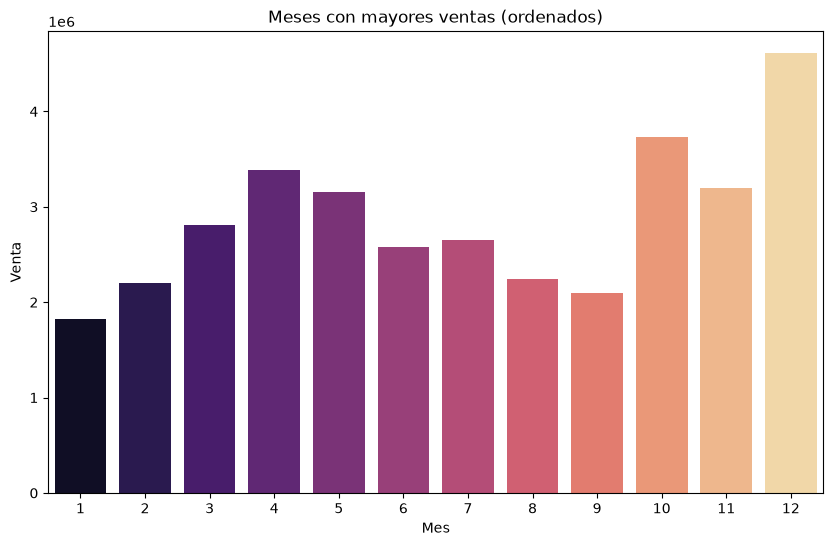

In [112]:
df_meses_ventas =  meses_mas_ventas.reset_index()
df_meses_ventas.columns = ["Mes", "Venta"]
plt.figure(figsize=(10,6))
sns.barplot(data=df_meses_ventas, x="Mes", y="Venta", palette="magma")
plt.title("Meses con mayores ventas (ordenados)")
plt.show()

# Ventas por Cuidad por mes

In [113]:
plt.figure(figsize=(10, 5))
sns.barplot(data=ventas_ciudad_mes, x="Product", y="Sales", color="skyblue")

# Personalizamos elementos con matplotlib
plt.title("Total de Ventas por Producto", fontsize=14)
plt.xlabel("Producto", fontsize=12)
plt.ylabel("Ventas Totales ($)", fontsize=12)
plt.xticks(rotation=90) # Rotar las etiquetas para que sean legibles
plt.grid(axis='y', linestyle='--', alpha=0.7) # Mostrar grilla solo horizontal

# Mostramos el resultado
plt.show()

ValueError: Could not interpret value `Product` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x500 with 0 Axes>

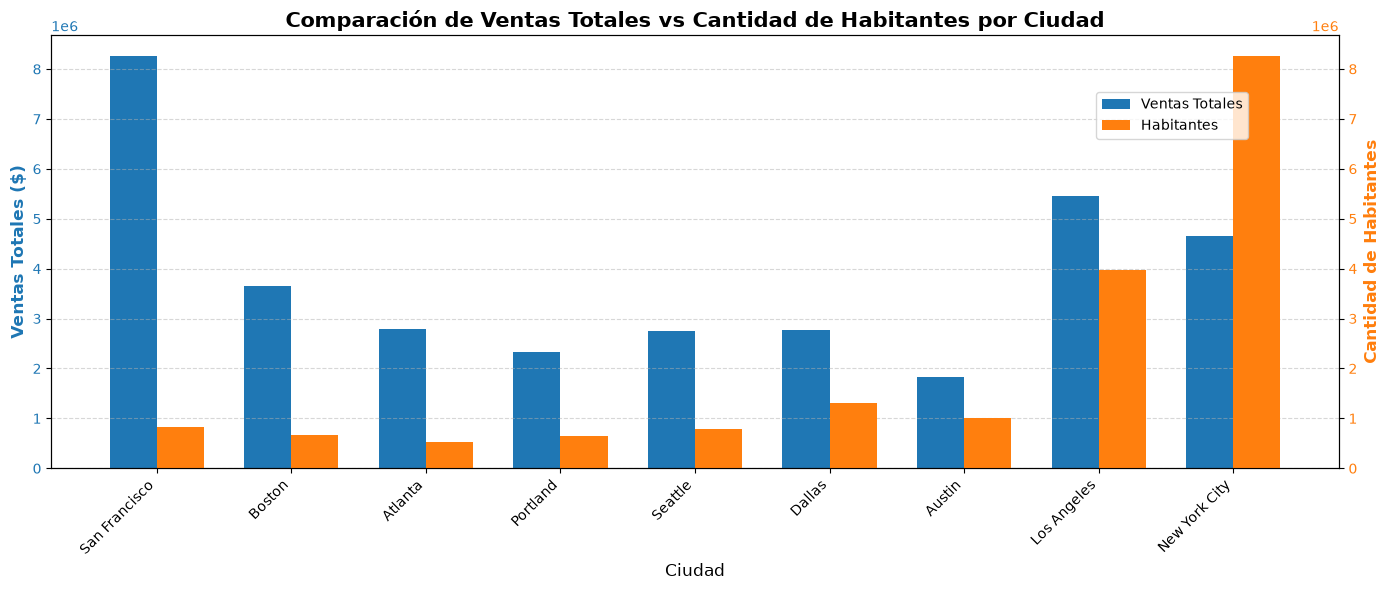

In [114]:
import matplotlib.pyplot as plt
import numpy as np

# Extraemos los datos del dataframe de comparación
ciudades = df_comparacion['Ciudad']
ventas = df_comparacion['Venta']
habitantes = df_comparacion['Habitantes']

# Configuramos las posiciones en el eje X y el ancho de las barras
x = np.arange(len(ciudades))
ancho = 0.35 

fig, ax1 = plt.subplots(figsize=(14, 6))

# Eje Y Izquierdo: Ventas
color_ventas = 'tab:blue'
ax1.set_xlabel('Ciudad', fontsize=12)
ax1.set_ylabel('Ventas Totales ($)', color=color_ventas, fontsize=12, fontweight='bold')
ax1.bar(x - ancho/2, ventas, ancho, label='Ventas Totales', color=color_ventas)
ax1.tick_params(axis='y', labelcolor=color_ventas)
ax1.set_xticks(x)
ax1.set_xticklabels(ciudades, rotation=45, ha='right')

# Eje Y Derecho: Habitantes
ax2 = ax1.twinx()  # Instancia un segundo eje que comparte el mismo eje X
color_hab = 'tab:orange'
ax2.set_ylabel('Cantidad de Habitantes', color=color_hab, fontsize=12, fontweight='bold')
ax2.bar(x + ancho/2, habitantes, ancho, label='Habitantes', color=color_hab)
ax2.tick_params(axis='y', labelcolor=color_hab)

# Título, grilla y leyenda conjunta
plt.title('Comparación de Ventas Totales vs Cantidad de Habitantes por Ciudad', fontsize=15, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.5)
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.85))

plt.tight_layout()
plt.show()